In [2]:
# ============================================================
# Notebook 02 — Preprocessing
# Load, clean, validate and visualise all three datasets
# Author: Nihaar Raut | 001309432
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path('../data/raw')
PROCESSED = Path('../data/processed')
FIGURES = Path('../outputs/figures')

# Load all three datasets
co2 = pd.read_csv(RAW / 'co2_monthly_global.csv', parse_dates=['date'])
ndvi = pd.read_csv(RAW / 'ndvi_monthly_regional.csv', parse_dates=['date'])
sst = pd.read_csv(RAW / 'sst_monthly_regional.csv', parse_dates=['date'])

print("=== CO₂ ===")
print(f"Shape: {co2.shape} | Missing: {co2.isna().sum().sum()}")

print("\n=== NDVI ===")
print(f"Shape: {ndvi.shape} | Missing: {ndvi.isna().sum().sum()}")
print(ndvi['region'].value_counts())

print("\n=== SST ===")
print(f"Shape: {sst.shape} | Missing: {sst.isna().sum().sum()}")
print(sst['region'].value_counts())

=== CO₂ ===
Shape: (300, 2) | Missing: 0

=== NDVI ===
Shape: (598, 3) | Missing: 0
region
amazon    299
sahel     299
Name: count, dtype: int64

=== SST ===
Shape: (600, 3) | Missing: 0
region
north_atlantic    300
indian_ocean      300
Name: count, dtype: int64


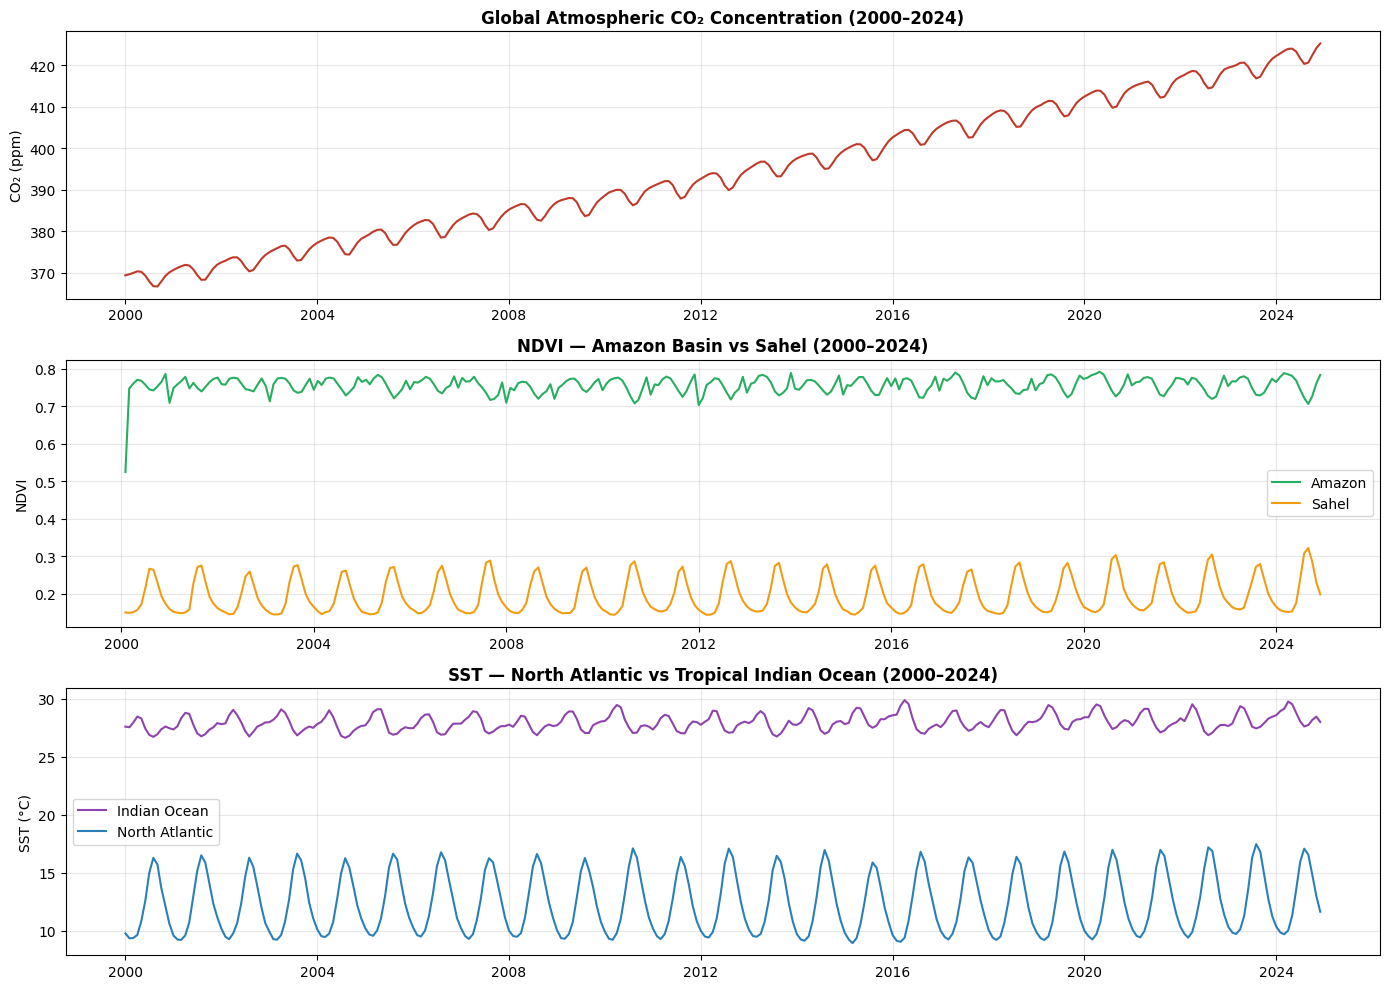

Figure saved.


In [3]:
# ============================================================
# Figure 02 — Raw Time Series Overview (All Indicators)
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# CO₂
axes[0].plot(co2['date'], co2['co2_mean'], color='#c0392b', linewidth=1.5)
axes[0].set_title('Global Atmospheric CO₂ Concentration (2000–2024)', fontweight='bold')
axes[0].set_ylabel('CO₂ (ppm)')
axes[0].grid(True, alpha=0.3)

# NDVI
colors_ndvi = {'amazon': '#27ae60', 'sahel': '#f39c12'}
for region, grp in ndvi.groupby('region'):
    axes[1].plot(grp['date'], grp['ndvi_mean'], 
                 label=region.capitalize(), 
                 color=colors_ndvi[region], linewidth=1.5)
axes[1].set_title('NDVI — Amazon Basin vs Sahel (2000–2024)', fontweight='bold')
axes[1].set_ylabel('NDVI')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# SST
colors_sst = {'north_atlantic': '#2980b9', 'indian_ocean': '#8e44ad'}
for region, grp in sst.groupby('region'):
    axes[2].plot(grp['date'], grp['sst_mean'], 
                 label=region.replace('_', ' ').title(), 
                 color=colors_sst[region], linewidth=1.5)
axes[2].set_title('SST — North Atlantic vs Tropical Indian Ocean (2000–2024)', fontweight='bold')
axes[2].set_ylabel('SST (°C)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / 'fig02_raw_timeseries_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

In [4]:
# ============================================================
# Stationarity Testing — Augmented Dickey-Fuller Test
# H0: Series has a unit root (non-stationary)
# Reject H0 if p-value < 0.05 → stationary
# ============================================================

from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna())
    p = result[1]
    stat = result[0]
    status = "STATIONARY" if p < 0.05 else "NON-STATIONARY"
    print(f"{name:<40} ADF: {stat:>8.3f}  p-value: {p:.4f}  → {status}")

print("=== ADF Stationarity Test Results ===\n")

# CO₂
adf_test(co2['co2_mean'], 'CO₂ (global)')

# NDVIpip install git-filter-repo
for region, grp in ndvi.groupby('region'):
    adf_test(grp['ndvi_mean'], f'NDVI ({region})')

# SST
for region, grp in sst.groupby('region'):
    adf_test(grp['sst_mean'], f'SST ({region})')

=== ADF Stationarity Test Results ===

CO₂ (global)                             ADF:    1.887  p-value: 0.9985  → NON-STATIONARY
NDVI (amazon)                            ADF:   -3.623  p-value: 0.0053  → STATIONARY
NDVI (sahel)                             ADF:   -2.448  p-value: 0.1287  → NON-STATIONARY
SST (indian_ocean)                       ADF:   -2.954  p-value: 0.0394  → STATIONARY
SST (north_atlantic)                     ADF:   -2.835  p-value: 0.0535  → NON-STATIONARY


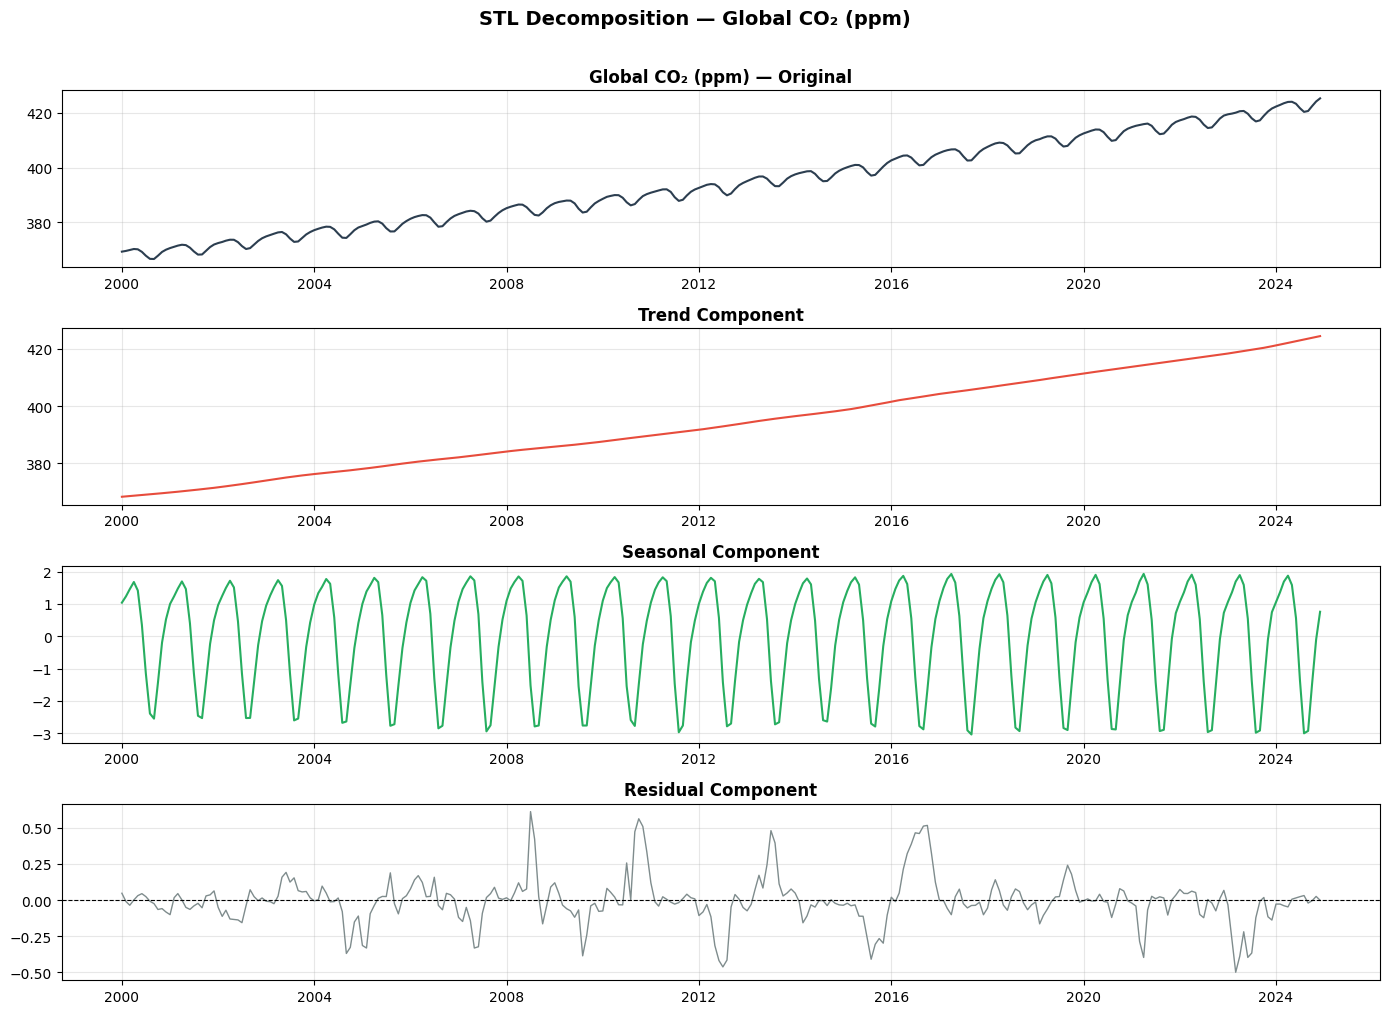

Saved: fig03_decomp_co2.png


In [5]:
# ============================================================
# Seasonal Decomposition
# Method: STL (Seasonal and Trend decomposition using Loess)
# Period: 12 (monthly data, annual seasonality)
# ============================================================

from statsmodels.tsa.seasonal import STL

def plot_decomposition(series, title, filename, period=12):
    stl = STL(series, period=period, robust=True)
    result = stl.fit()
    
    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
    
    axes[0].plot(series.index, series.values, color='#2c3e50', linewidth=1.5)
    axes[0].set_title(f'{title} — Original', fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(series.index, result.trend, color='#e74c3c', linewidth=1.5)
    axes[1].set_title('Trend Component', fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    axes[2].plot(series.index, result.seasonal, color='#27ae60', linewidth=1.5)
    axes[2].set_title('Seasonal Component', fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    
    axes[3].plot(series.index, result.resid, color='#7f8c8d', linewidth=1.0)
    axes[3].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[3].set_title('Residual Component', fontweight='bold')
    axes[3].grid(True, alpha=0.3)
    
    plt.suptitle(f'STL Decomposition — {title}', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES / filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

# CO₂
co2_series = co2.set_index('date')['co2_mean']
plot_decomposition(co2_series, 'Global CO₂ (ppm)', 'fig03_decomp_co2.png')

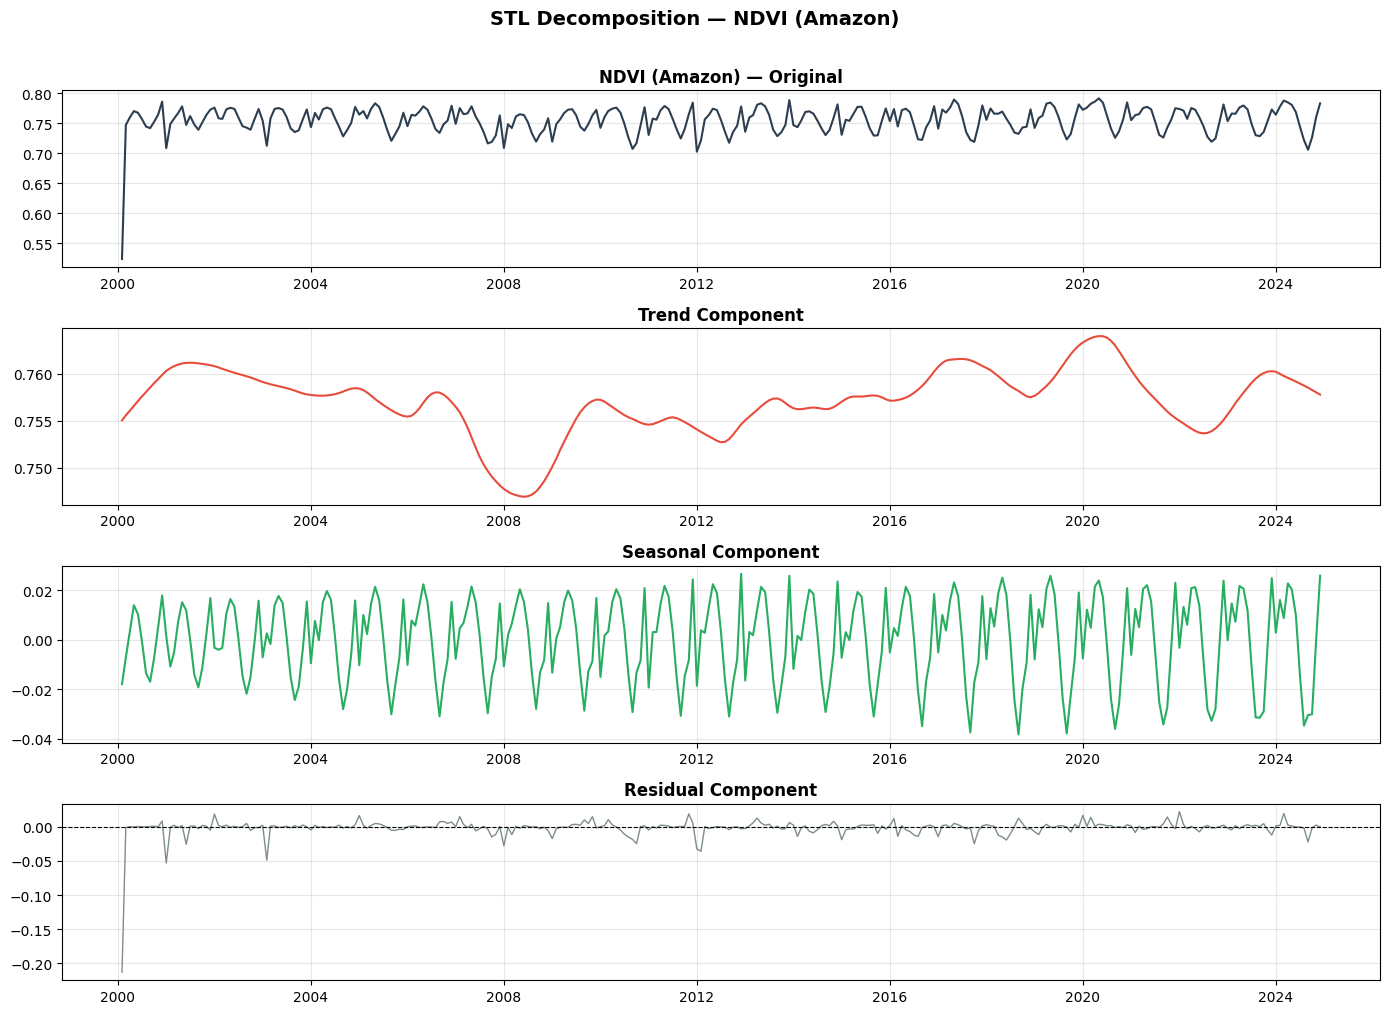

Saved: fig03_decomp_ndvi_amazon.png


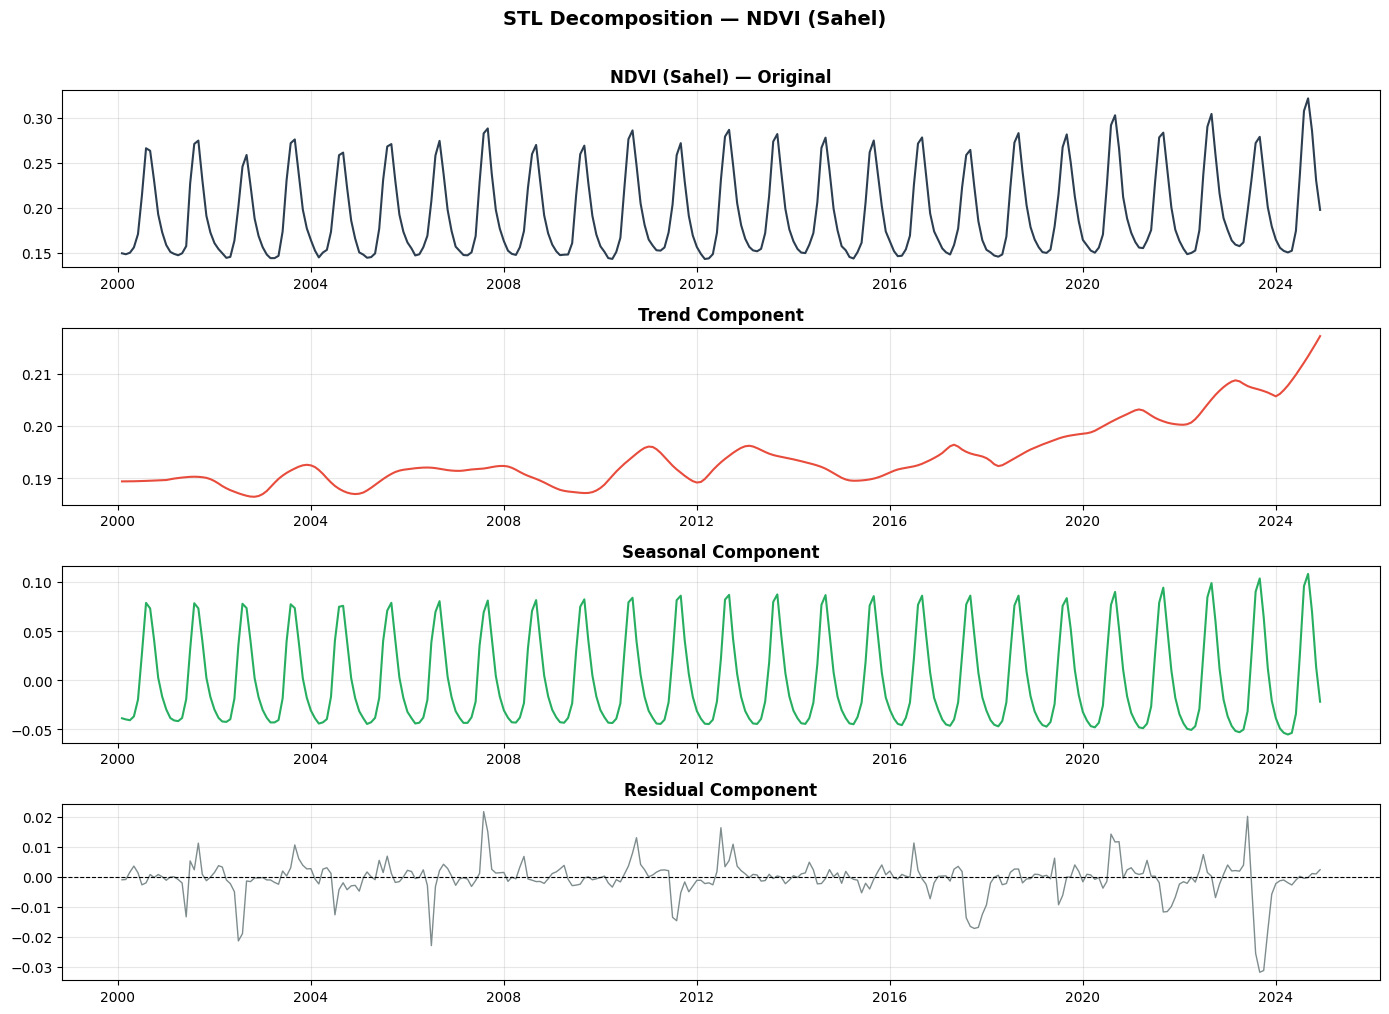

Saved: fig03_decomp_ndvi_sahel.png


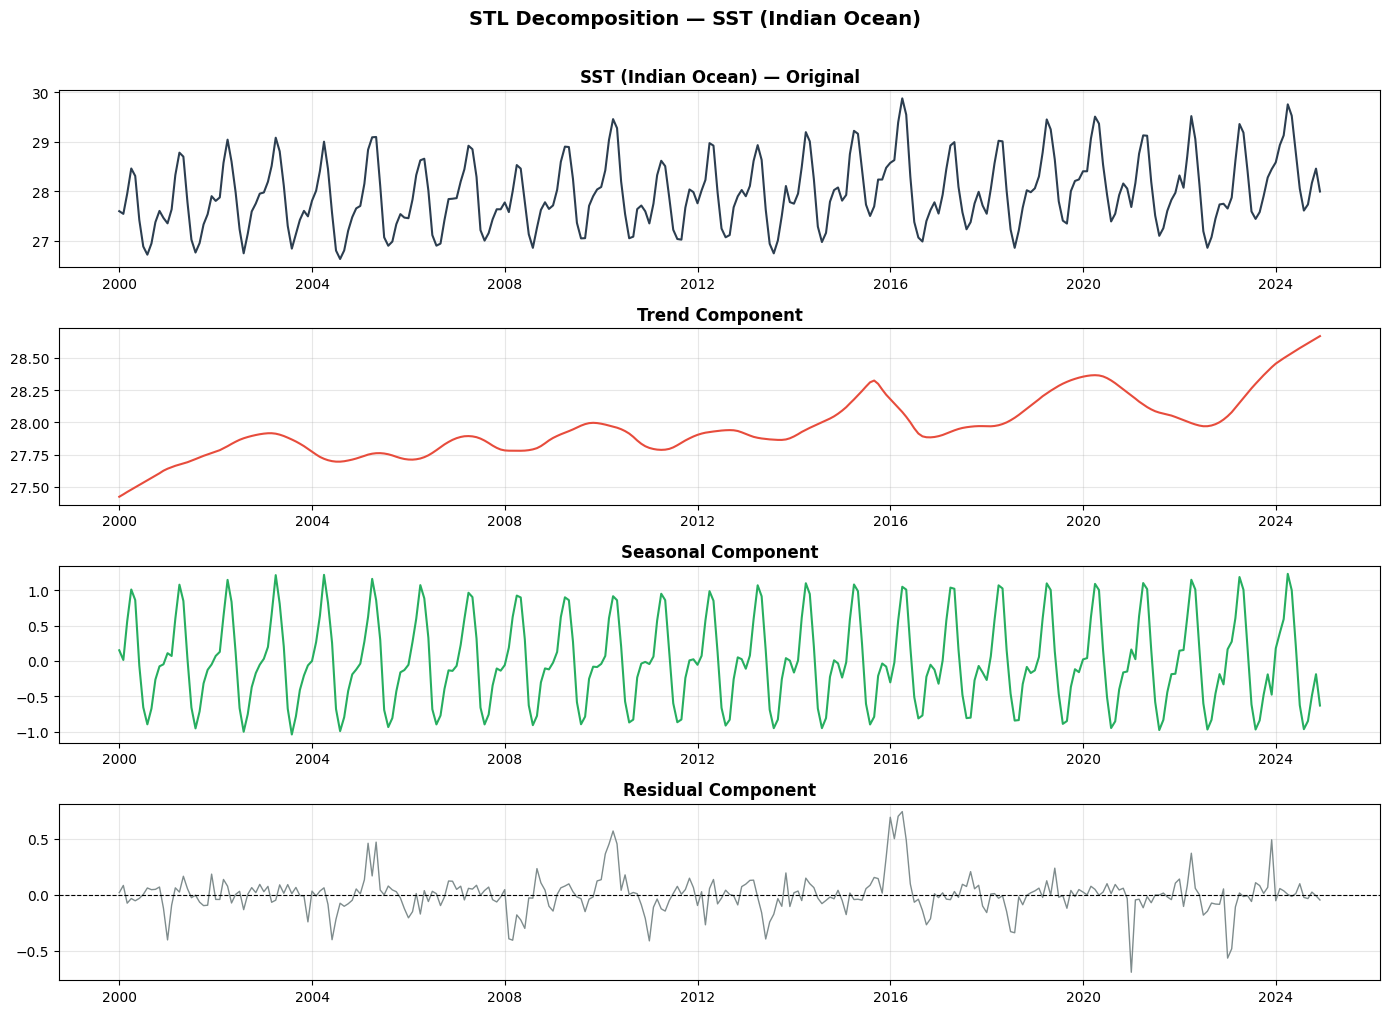

Saved: fig03_decomp_sst_indian_ocean.png


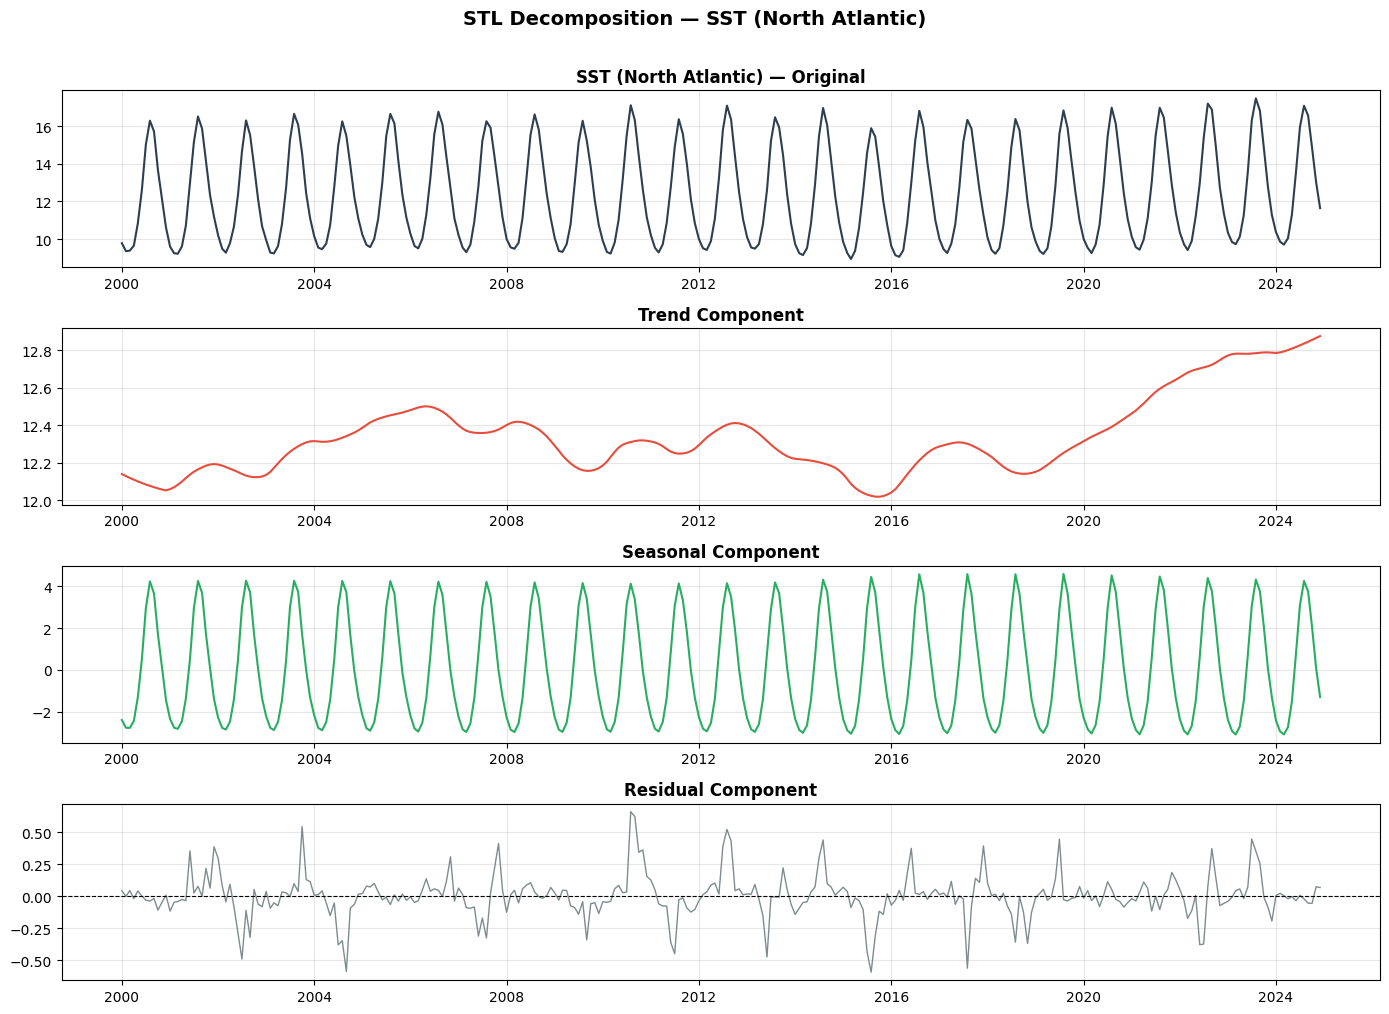

Saved: fig03_decomp_sst_north_atlantic.png


In [6]:
# NDVI decompositions
for region, grp in ndvi.groupby('region'):
    series = grp.set_index('date')['ndvi_mean']
    plot_decomposition(series, f'NDVI ({region.capitalize()})', 
                      f'fig03_decomp_ndvi_{region}.png')

# SST decompositions
for region, grp in sst.groupby('region'):
    series = grp.set_index('date')['sst_mean']
    plot_decomposition(series, f'SST ({region.replace("_", " ").title()})', 
                      f'fig03_decomp_sst_{region}.png')

In [8]:
# ============================================================
# Train/Test Split — Chronological 80/20
# No shuffling — time series order must be preserved
# Train: 2000-2020 | Test: 2021-2024
# ============================================================

def split_series(df, value_col, test_start='2021-01-01'):
    train = df[df['date'] < test_start].copy()
    test = df[df['date'] >= test_start].copy()
    print(f"Train: {train['date'].min().date()} to {train['date'].max().date()} ({len(train)} obs)")
    print(f"Test:  {test['date'].min().date()} to {test['date'].max().date()} ({len(test)} obs)")
    return train, test

# CO₂
print("=== CO₂ ===")
co2_train, co2_test = split_series(co2, 'co2_mean')

# NDVI
print("\n=== NDVI Amazon ===")
ndvi_amazon = ndvi[ndvi['region'] == 'amazon'].reset_index(drop=True)
ndvi_amazon_train, ndvi_amazon_test = split_series(ndvi_amazon, 'ndvi_mean')

print("\n=== NDVI Sahel ===")
ndvi_sahel = ndvi[ndvi['region'] == 'sahel'].reset_index(drop=True)
ndvi_sahel_train, ndvi_sahel_test = split_series(ndvi_sahel, 'ndvi_mean')

# SST
print("\n=== SST North Atlantic ===")
sst_atlantic = sst[sst['region'] == 'north_atlantic'].reset_index(drop=True)
sst_atlantic_train, sst_atlantic_test = split_series(sst_atlantic, 'sst_mean')

print("\n=== SST Indian Ocean ===")
sst_indian = sst[sst['region'] == 'indian_ocean'].reset_index(drop=True)
sst_indian_train, sst_indian_test = split_series(sst_indian, 'sst_mean')

=== CO₂ ===
Train: 2000-01-01 to 2020-12-01 (252 obs)
Test:  2021-01-01 to 2024-12-01 (48 obs)

=== NDVI Amazon ===
Train: 2000-02-01 to 2020-12-01 (251 obs)
Test:  2021-01-01 to 2024-12-01 (48 obs)

=== NDVI Sahel ===
Train: 2000-02-01 to 2020-12-01 (251 obs)
Test:  2021-01-01 to 2024-12-01 (48 obs)

=== SST North Atlantic ===
Train: 2000-01-01 to 2020-12-01 (252 obs)
Test:  2021-01-01 to 2024-12-01 (48 obs)

=== SST Indian Ocean ===
Train: 2000-01-01 to 2020-12-01 (252 obs)
Test:  2021-01-01 to 2024-12-01 (48 obs)


In [9]:
# ============================================================
# Save Processed Train/Test Splits to data/processed/
# ============================================================

# CO₂
co2_train.to_csv(PROCESSED / 'co2_train.csv', index=False)
co2_test.to_csv(PROCESSED / 'co2_test.csv', index=False)

# NDVI
ndvi_amazon_train.to_csv(PROCESSED / 'ndvi_amazon_train.csv', index=False)
ndvi_amazon_test.to_csv(PROCESSED / 'ndvi_amazon_test.csv', index=False)
ndvi_sahel_train.to_csv(PROCESSED / 'ndvi_sahel_train.csv', index=False)
ndvi_sahel_test.to_csv(PROCESSED / 'ndvi_sahel_test.csv', index=False)

# SST
sst_atlantic_train.to_csv(PROCESSED / 'sst_atlantic_train.csv', index=False)
sst_atlantic_test.to_csv(PROCESSED / 'sst_atlantic_test.csv', index=False)
sst_indian_train.to_csv(PROCESSED / 'sst_indian_train.csv', index=False)
sst_indian_test.to_csv(PROCESSED / 'sst_indian_test.csv', index=False)

print("All train/test splits saved to data/processed/")
print(f"Files saved: {len(list(PROCESSED.glob('*.csv')))}")

All train/test splits saved to data/processed/
Files saved: 10
